[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/da380/PartIIStatistics/blob/main/notebooks/08_resampling_and_monte_carlo.ipynb)

# 8. Resampling and Monte Carlo methods

**What you should get out of this notebook**

- Use simulation to answer probability questions for which no formula is to hand.
- Understand the bootstrap well enough to apply it to fitted parameters, correlations and other awkward statistics, and to know when it fails.
- Use permutation tests as an assumption-free alternative to the classical tests.
- Use cross-validation to choose between models of different complexity.
- Recognise that dependent data need special treatment.

**Tools introduced**

- `rng.choice(..., replace=True)`, `rng.permutation`
- `stats.bootstrap` with `paired=True` and `method=`
- `stats.permutation_test`
- `np.polyfit` in a cross-validation loop

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd

rng = np.random.default_rng(1)          # random number generator with a fixed seed
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
DATA = "https://raw.githubusercontent.com/da380/PartIIStatistics/main/data/"

## Simulation as a universal tool

Several times in this course we have answered a question by simulation rather than by formula: the sampling distribution of the mean (Notebook 2), the propagation of errors (Notebook 3), the power of a test (Notebook 4), the scatter of fitted parameters (Notebook 5), and the posterior distribution (Notebook 7). The principle is always the same: **if you can simulate the process that generates the data, you can estimate any probability or distribution by generating many realisations and counting.** Formulae are quicker and more insightful when they exist; simulation works when they do not.

An example. The largest gap between successive magnitude 6.5+ earthquakes in the 2014–2023 catalogue is about three months. Is that surprisingly long for a random (Poisson) process at the observed rate? The distribution of the *longest* of 440-odd exponential gaps has no convenient closed form, but simulating it is trivial.

442 gaps, mean 8.3 days, longest 93 days
simulated Poisson process: longest gap has median 53 days, 95% of runs below 74 days
P(longest gap ≥ observed) = 0.007


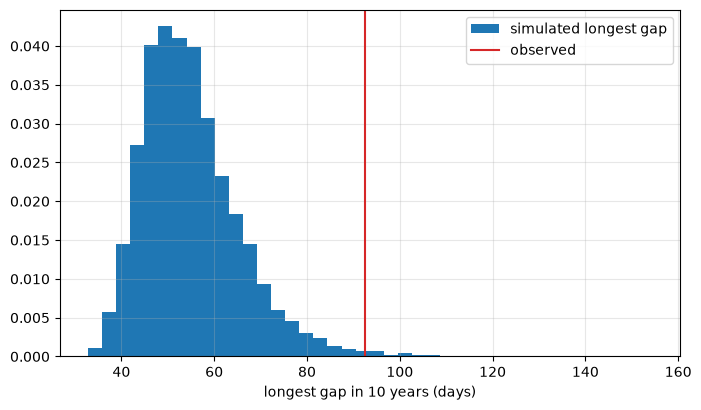

In [ ]:
quakes = pd.read_csv(DATA + "usgs_earthquakes_M5_2014_2023.csv", parse_dates=["time"])
big = quakes[quakes["mag"] >= 6.5].sort_values("time")
gaps = np.diff(big["time"].to_numpy()) / np.timedelta64(1, "D")
n_gaps, rate = len(gaps), 1 / gaps.mean()
print(f"{n_gaps} gaps, mean {gaps.mean():.1f} days, longest {gaps.max():.0f} days")

longest = stats.expon(scale=1/rate).rvs((10_000, n_gaps), random_state=rng).max(axis=1)
print(f"simulated Poisson process: longest gap has median {np.median(longest):.0f} days, 95% of runs below {np.percentile(longest, 95):.0f} days")
print(f"P(longest gap ≥ observed) = {np.mean(longest >= gaps.max()):.3f}")

fig, ax = plt.subplots()
ax.hist(longest, bins=40, density=True, label="simulated longest gap")
ax.axvline(gaps.max(), color="C3", label="observed"); ax.set(xlabel="longest gap in 10 years (days)"); ax.legend()
plt.show()

The observed longest gap is longer than in 99% of the simulated runs. This is the other face of the clustering found in Notebook 4: when events bunch together, the quiet intervals *between* bunches are longer than a Poisson process with the same average rate would produce. Notice that this is a hypothesis test whose null distribution was obtained by simulation rather than from a formula; the p-value is the fraction of simulated runs at least as extreme as the observation.

## The bootstrap

Simulation needs a model of the process. The bootstrap, introduced in Notebook 2, replaces the model by the data themselves: the empirical distribution of the sample stands in for the unknown true distribution, and "repeating the experiment" becomes drawing $n$ values from the sample *with replacement*. Here it is by hand, for the standard error of a mean, so that the mechanics are clear.

In [ ]:
faithful = pd.read_csv(DATA + "old_faithful.csv")
waiting = faithful["waiting"].to_numpy()
duration = faithful["eruptions"].to_numpy()
n = len(waiting)

boot_means = np.array([rng.choice(waiting, size=n, replace=True).mean() for _ in range(5000)])
print(f"bootstrap standard error of the mean = {boot_means.std():.3f};  formula s/√n = {stats.sem(waiting):.3f}")
print(f"percentile 95% interval = [{np.percentile(boot_means, 2.5):.2f}, {np.percentile(boot_means, 97.5):.2f}]")

bootstrap standard error of the mean = 0.829;  formula s/√n = 0.824
percentile 95% interval = [69.28, 72.53]


### Bootstrapping a fitted parameter

The bootstrap comes into its own for statistics with no simple formula, or where the formula rests on assumptions we doubt. In Notebook 5 we fitted a warming rate to the GISTEMP series since 1970, using a standard error that assumed independent normal residuals. A **paired bootstrap** resamples the $(x_i, y_i)$ pairs together and refits each time; it makes no assumption about the residual distribution (though it still assumes the pairs are independent, a point we return to below). For a correlation coefficient the same paired resampling applies.

In [ ]:
gis = pd.read_csv(DATA + "gistemp_global_annual.csv")
recent = gis[gis["year"] >= 1970]
yr, T = recent["year"].to_numpy(dtype=float), recent["anomaly"].to_numpy()

slope = lambda x, y: stats.linregress(x, y).slope
res = stats.bootstrap((yr, T), slope, paired=True, n_resamples=5000, random_state=rng)
lr = stats.linregress(yr, T)
print(f"warming rate: {10*lr.slope:.3f} °C/decade;  formula SE {10*lr.stderr:.4f};  bootstrap SE {10*res.standard_error:.4f};"
      f"  bootstrap 95% CI [{10*res.confidence_interval.low:.3f}, {10*res.confidence_interval.high:.3f}]")

corr = lambda x, y: stats.pearsonr(x, y).statistic
res = stats.bootstrap((duration, waiting), corr, paired=True, n_resamples=5000, random_state=rng)
r = stats.pearsonr(duration, waiting)
print(f"correlation of duration and waiting: r = {r.statistic:.3f};  bootstrap 95% CI [{res.confidence_interval.low:.3f}, {res.confidence_interval.high:.3f}];"
      f"  parametric CI [{r.confidence_interval().low:.3f}, {r.confidence_interval().high:.3f}]")

warming rate: 0.202 °C/decade;  formula SE 0.0088;  bootstrap SE 0.0100;  bootstrap 95% CI [0.183, 0.222]


correlation of duration and waiting: r = 0.901;  bootstrap 95% CI [0.882, 0.916];  parametric CI [0.876, 0.921]


In both cases the bootstrap and the parametric formula agree reasonably well, which is reassuring about the formula's assumptions in these cases. Where they disagree, it is usually the formula's assumptions that are at fault.

### When the bootstrap fails

The bootstrap is not magic. It relies on the sample being a fair representation of the population, which fails when:

- **The sample is small.** With five values there are few distinct resamples and the tails of the distribution are unrepresented. Roughly, do not trust bootstrap intervals from fewer than 20 or so observations.
- **The statistic depends on the extremes.** The bootstrap distribution of the sample maximum, say, is badly behaved because a resample can never exceed the observed maximum. The largest earthquake or the highest flood in a record cannot be bootstrapped usefully; extreme-value theory exists for that.
- **The data are dependent.** Resampling individual values destroys the dependence structure of a time series or a spatial field, and the bootstrap then underestimates the uncertainty, sometimes severely. The remedy is to resample *blocks* of consecutive values long enough to preserve the dependence. We show this below.

In [ ]:
# An autocorrelated series: each value is 0.7 times the previous plus noise
def ar1(n, phi=0.7):
    z = np.empty(n); z[0] = rng.normal()
    for i in range(1, n):
        z[i] = phi*z[i-1] + rng.normal()
    return z

n, phi = 200, 0.7
true_se = np.std([ar1(n, phi).mean() for _ in range(2000)])          # the truth, by simulating the process

z = ar1(n, phi)
naive = np.std([rng.choice(z, n).mean() for _ in range(2000)])

block = 20
starts = np.arange(0, n - block + 1)
def block_resample(z):
    idx = rng.choice(starts, size=n // block)                          # choose blocks
    return np.concatenate([z[i:i+block] for i in idx])
blocked = np.std([block_resample(z).mean() for _ in range(2000)])

print(f"standard error of the mean of an autocorrelated series (n = {n}):")
print(f"   true (by simulation)  {true_se:.3f}")
print(f"   formula s/√n          {stats.sem(z):.3f}")
print(f"   naive bootstrap       {naive:.3f}")
print(f"   block bootstrap       {blocked:.3f}")

standard error of the mean of an autocorrelated series (n = 200):
   true (by simulation)  0.229
   formula s/√n          0.091
   naive bootstrap       0.090
   block bootstrap       0.175


The naive bootstrap and the textbook formula both underestimate the true uncertainty by more than a factor of two, because they treat 200 correlated values as 200 independent ones. The block bootstrap gets much closer. This is the same problem that afflicted the formal error on the warming rate in Notebook 5; a block bootstrap of the residuals is one practical way to correct it.

## Permutation tests

Classical two-sample tests assume a distribution (the $t$-test) or work with ranks (Mann–Whitney). A **permutation test** makes only one assumption: that under the null hypothesis the group labels are arbitrary, so any relabelling of the data is as likely as the observed one. The procedure is:

1. Compute the test statistic (say, the difference of means) for the observed labelling.
2. Shuffle the labels at random and recompute the statistic. Repeat many times.
3. The p-value is the fraction of shuffles giving a statistic at least as extreme as the observed one.

This works for *any* statistic, with no distributional assumptions, and is exact in the sense that the Type I error rate is guaranteed. `stats.permutation_test` does the work. We revisit the question from Notebook 4 of whether waiting times changed between the first and second halves of the record, and then a question no classical test covers directly: whether the *spread* of waiting times differs between the two halves.

difference of means: observed -0.21 min,  permutation p = 0.895  (Welch t-test p = 0.901)


difference of standard deviations: observed -0.22 min,  permutation p = 0.763


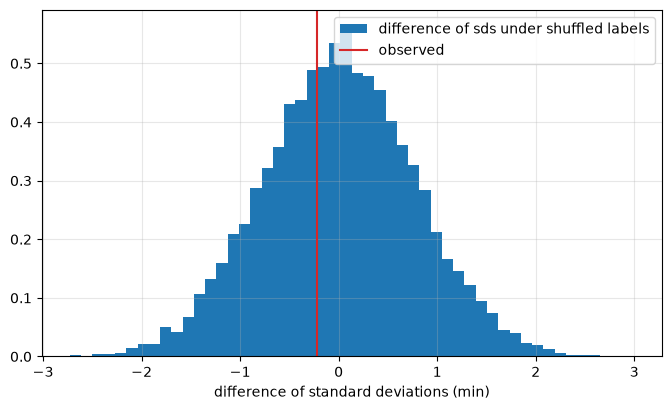

In [ ]:
half = n_half = len(waiting) // 2
g1, g2 = waiting[:half], waiting[half:]

diff_means = lambda a, b: a.mean() - b.mean()
res = stats.permutation_test((g1, g2), diff_means, n_resamples=10_000, random_state=rng)
print(f"difference of means: observed {res.statistic:.2f} min,  permutation p = {res.pvalue:.3f}  (Welch t-test p = {stats.ttest_ind(g1, g2, equal_var=False).pvalue:.3f})")

diff_sd = lambda a, b: a.std(ddof=1) - b.std(ddof=1)
res = stats.permutation_test((g1, g2), diff_sd, n_resamples=10_000, random_state=rng)
print(f"difference of standard deviations: observed {res.statistic:.2f} min,  permutation p = {res.pvalue:.3f}")

fig, ax = plt.subplots()
ax.hist(res.null_distribution, bins=50, density=True, label="difference of sds under shuffled labels")
ax.axvline(res.statistic, color="C3", label="observed"); ax.set(xlabel="difference of standard deviations (min)"); ax.legend()
plt.show()

Neither the mean nor the spread of waiting times differs detectably between the two halves. The histogram is the null distribution built by shuffling: the observed value sits comfortably within it.

A permutation test for correlation works the same way, by shuffling one variable relative to the other; `stats.permutation_test` with `permutation_type="pairings"` does it. This is the honest way to obtain a p-value for a correlation when the data are not normal.

## Cross-validation: choosing a model's complexity

In Notebook 5 we saw that adding parameters always improves the fit to the data in hand, so the fit itself cannot tell us when to stop. **Cross-validation** asks a different question: how well does the model predict data it was *not* fitted to? The simplest form, **leave-one-out**, drops each point in turn, fits to the rest, predicts the dropped point, and accumulates the prediction errors. A model that is too simple predicts poorly because it misses real structure; one that is too complex predicts poorly because it has fitted noise. The prediction error is minimised in between.

First a synthetic example, where we know the truth is a quadratic.

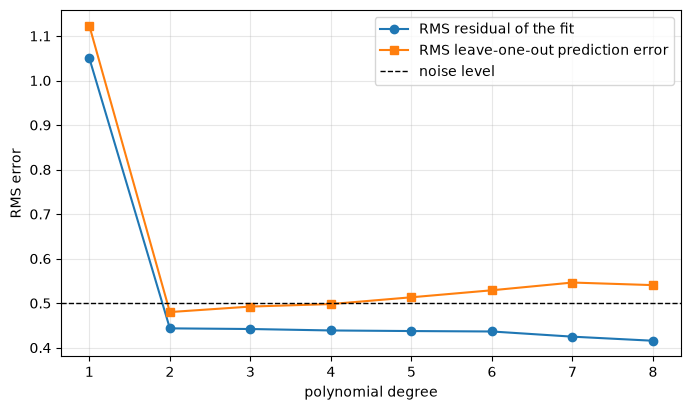

In [ ]:
def loo_rms(t, y, degree):
    # root-mean-square leave-one-out prediction error of a polynomial fit
    errs = []
    for i in range(len(t)):
        mask = np.arange(len(t)) != i
        errs.append(y[i] - np.polyval(np.polyfit(t[mask], y[mask], degree), t[i]))
    return np.sqrt(np.mean(np.square(errs)))

t = np.linspace(-1, 1, 40)
y = 1 + 2*t - 3*t**2 + stats.norm(0, 0.5).rvs(40, random_state=rng)

degrees = np.arange(1, 9)
fit_rms = [np.sqrt(np.mean((y - np.polyval(np.polyfit(t, y, d), t))**2)) for d in degrees]
cv_rms = [loo_rms(t, y, d) for d in degrees]

fig, ax = plt.subplots()
ax.plot(degrees, fit_rms, "o-", label="RMS residual of the fit")
ax.plot(degrees, cv_rms, "s-", label="RMS leave-one-out prediction error")
ax.axhline(0.5, color="k", ls="--", lw=1, label="noise level")
ax.set(xlabel="polynomial degree", ylabel="RMS error"); ax.legend()
plt.show()

The fit residual falls steadily with degree, as it must. The prediction error drops sharply at degree 2, the true model, and then slowly *rises* as higher-degree terms fit the noise and predict worse. Cross-validation identifies the right complexity without knowing the noise level.

Now the annual CO₂ series. Here the caveat about dependence bites: consecutive years are strongly correlated, so a left-out year is nearly determined by its neighbours and leave-one-out is too easy a test. It keeps rewarding extra terms, because the residuals contain slow variations (the growth rate changed from decade to decade) that a higher-degree polynomial can track. The honest alternative for a time series is to leave out **blocks** of consecutive years, so that the model must predict a whole decade it has not seen.

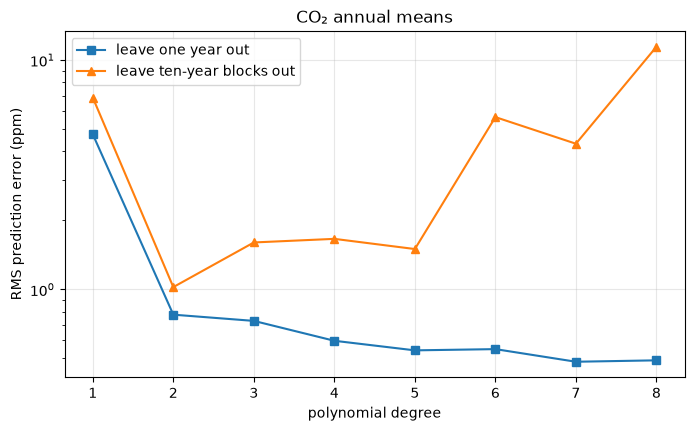

degree 1: leave-one-out 4.74 ppm,  ten-year blocks 6.86 ppm
degree 2: leave-one-out 0.78 ppm,  ten-year blocks 1.02 ppm
degree 3: leave-one-out 0.73 ppm,  ten-year blocks 1.60 ppm
degree 4: leave-one-out 0.60 ppm,  ten-year blocks 1.66 ppm
degree 5: leave-one-out 0.54 ppm,  ten-year blocks 1.50 ppm
degree 6: leave-one-out 0.55 ppm,  ten-year blocks 5.64 ppm
degree 7: leave-one-out 0.48 ppm,  ten-year blocks 4.32 ppm
degree 8: leave-one-out 0.49 ppm,  ten-year blocks 11.43 ppm


In [ ]:
def block_cv_rms(t, y, degree, block):
    # root-mean-square prediction error, leaving out contiguous blocks
    errs = []
    for start in range(0, len(t), block):
        test = np.zeros(len(t), dtype=bool); test[start:start + block] = True
        p = np.polyfit(t[~test], y[~test], degree)
        errs.extend(y[test] - np.polyval(p, t[test]))
    return np.sqrt(np.mean(np.square(errs)))

co2 = pd.read_csv(DATA + "mauna_loa_co2_monthly.csv").groupby("year")["co2"].mean().loc[1959:2025]
tc = (co2.index.to_numpy(dtype=float) - 1992) / 33         # centred and scaled to [-1, 1] for numerical stability
c = co2.to_numpy()

loo = [loo_rms(tc, c, d) for d in degrees]
blk = [block_cv_rms(tc, c, d, block=10) for d in degrees]
fig, ax = plt.subplots()
ax.semilogy(degrees, loo, "s-", label="leave one year out")
ax.semilogy(degrees, blk, "^-", label="leave ten-year blocks out")
ax.set(xlabel="polynomial degree", ylabel="RMS prediction error (ppm)", title="CO₂ annual means"); ax.legend()
plt.show()
for d, a, b in zip(degrees, loo, blk):
    print(f"degree {d}: leave-one-out {a:.2f} ppm,  ten-year blocks {b:.2f} ppm")

Leave-one-out prefers ever higher degrees; leaving out decades prefers the quadratic, and shows that high-degree polynomials predict unseen decades disastrously. When in doubt about dependence, make the validation harder, not easier. Cross-validation is the workhorse of model selection in machine learning, where the same over-fitting problem appears with far more parameters, and the same caution about dependent data applies.

## Summary

- If you can simulate the process, you can compute any probability or null distribution by counting.
- The bootstrap estimates the uncertainty of almost any statistic by resampling the data with replacement; use the paired version for fitted parameters and correlations.
- The bootstrap fails for small samples, for extremes, and for dependent data, where blocks must be resampled.
- Permutation tests give exact p-values for any statistic under the assumption of exchangeable labels.
- Cross-validation chooses model complexity by prediction error on held-out data, not by goodness of fit.

**Where next.** The four tools in this notebook, together with `scipy.stats`, `scipy.optimize` and a basic MCMC sampler, cover a large fraction of everyday data analysis in the Earth sciences. Beyond them lie time-series analysis (spectral methods, autocorrelation), spatial statistics (kriging, geostatistics), extreme-value theory (floods, earthquakes, storms), and multivariate methods (principal components, clustering, classification). Each builds directly on the ideas here.

## Exercises

### Exercise 1

Obtain a bootstrap 95% confidence interval for Spearman's rank correlation between eruption duration and waiting time, using `stats.bootstrap` with `paired=True`. Compare it with the Pearson interval computed above.

In [ ]:
# Your code here

<details>
<summary><b>Solution</b> (click to expand)</summary>

```python
rho = lambda x, y: stats.spearmanr(x, y).statistic
res = stats.bootstrap((duration, waiting), rho, paired=True, n_resamples=5000, random_state=rng)
print(f"Spearman ρ = {rho(duration, waiting):.3f},  bootstrap 95% CI [{res.confidence_interval.low:.3f}, {res.confidence_interval.high:.3f}]")
```

The rank correlation is a little lower than Pearson's $r$ (about 0.78 against 0.90), because the relationship is dominated by the two clusters rather than by a linear trend within them, and its interval is correspondingly shifted.

</details>

### Exercise 2

Use a permutation test to decide whether the *median* waiting time differs between the eruptions in the first and second halves of the record, and between short and long eruptions. For the second comparison, how does the permutation p-value compare with the Mann–Whitney p-value from Notebook 4? (Note: `stats.permutation_test` reports p-values no smaller than about $1/n_{\text{resamples}}$.)

In [ ]:
# Your code here

<details>
<summary><b>Solution</b> (click to expand)</summary>

```python
diff_median = lambda a, b: np.median(a) - np.median(b)
for name, (a, b) in [("first vs second half", (waiting[:half], waiting[half:])),
                     ("short vs long eruptions", (waiting[duration < 3], waiting[duration >= 3]))]:
    res = stats.permutation_test((a, b), diff_median, n_resamples=10_000, random_state=rng)
    print(f"{name:25s}: difference of medians = {res.statistic:5.1f} min,  p = {res.pvalue:.4f}")
```

The halves do not differ. For short versus long eruptions no permutation among the 10,000 comes close to the observed difference, so the p-value is reported as the smallest resolvable value, about $10^{-4}$; the Mann–Whitney test, which has an analytical null distribution, can report $10^{-42}$. Both say the same thing.

</details>

### Exercise 3

Apply cross-validation to the *whole* GISTEMP series (1880 onwards) with polynomials of degree 1 to 8, both leaving one year out and leaving ten-year blocks out. Which degree does each criterion prefer? Plot the data with the polynomial the block criterion chooses. Explain the difference between the two criteria.

In [ ]:
# Your code here

<details>
<summary><b>Solution</b> (click to expand)</summary>

```python
yr_all = gis["year"].to_numpy(dtype=float); T_all = gis["anomaly"].to_numpy()
ts = (yr_all - yr_all.mean()) / (yr_all.max() - yr_all.mean())
loo = [loo_rms(ts, T_all, d) for d in degrees]
blk = [block_cv_rms(ts, T_all, d, block=10) for d in degrees]
for d, a, b in zip(degrees, loo, blk):
    print(f"degree {d}: leave-one-out {a:.4f} °C,  ten-year blocks {b:.4f} °C")
best = degrees[np.argmin(blk)]
fig, ax = plt.subplots()
ax.plot(yr_all, T_all, ".", label="GISTEMP annual anomaly")
ax.plot(yr_all, np.polyval(np.polyfit(ts, T_all, best), ts), "C1", label=f"degree {best} polynomial")
ax.set(xlabel="year", ylabel="anomaly (°C)"); ax.legend(); plt.show()
```

Leave-one-out keeps improving slowly all the way to degree 8. Leaving out decades gives a clear minimum near degree 4, with the error rising steeply above degree 5 as the polynomial fails to predict decades it has not seen. Neighbouring years are positively correlated, so a single left-out year is partly predictable from its neighbours even by a model that has fitted noise, and leave-one-out is biased towards complexity. (And, as ever, a polynomial fitted to this record has no business being extrapolated.)

</details>